In [1]:
from astropy.io import fits
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

In [2]:
# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

data_files = glob.glob('data/spectra_data_100k*.pkl')
data_files = sorted(data_files)  # Ordena para garantizar un orden consistente

# Inicializar el diccionario donde se acumularán los datos
spectra_data = {}

# Cargar y combinar los datos de cada archivo encontrado
for file in data_files:
    with open(file, 'rb') as f:
        data_part = pickle.load(f)
    spectra_data.update(data_part)

print(f"Se han cargado {len(spectra_data)} espectros a partir de {len(data_files)} archivos.")

file_names = list(spectra_data.keys())
fluxes = [spectra_data[f]["flux"] for f in file_names]
wavelengths = [spectra_data[f]["wavelength"] for f in file_names]
redshifts = [spectra_data[f]["redshift"] for f in file_names]

# Concatenar flujo y longitud de onda como entrada al modelo
X = np.stack([fluxes, wavelengths], axis=1)  # Ahora tiene 10000 características por muestra
y = np.array(redshifts)

# Normalización
nsamples, nchannels, npoints = X.shape
X = X.reshape(nsamples, -1)

# scaler = StandardScaler()
# X = scaler.fit_transform(X)

with open('extra/scaler_modelCNN_UPD_100ktest.pkl', 'rb') as f:
    scaler = pickle.load(f)
X = scaler.transform(X)

X = X.reshape(nsamples, nchannels, npoints)

# with open('extra/scaler_modelCNN_UPD_100ktest.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.00001, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convertir a tensores de PyTorch y mover a GPU si está disponible
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

# Crear DataSets y DataLoaders
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

Usando dispositivo: cuda
Se han cargado 100000 espectros a partir de 10 archivos.


In [ ]:
# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Número de puntos en cada espectro
num_points = 5000

# Definir el modelo CNN en PyTorch con dropout para regularización
class CNN(nn.Module):
    def __init__(self, num_points):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            # Bloque 1
            nn.Conv1d(in_channels=2, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            # Bloque 2
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            # Bloque 3
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            # Bloque 4 (capa adicional)
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            # Bloque 5 (capa adicional)
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # Con 5 capas de max pooling, la dimensión se reduce en un factor de 2^5 = 32
        conv_output_size = num_points // 32
        self.fc_layers = nn.Sequential(
            nn.Linear(256 * conv_output_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),  # Regularización con Dropout
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

scaler = StandardScaler()

# Instanciar el modelo y moverlo a GPU si está disponible
modelCNN = CNN(num_points).to(device)

# Definir la función de pérdida
criterion = nn.MSELoss()

# Utilizar Adam con un weight decay para regularización L2
optimizer = optim.Adam(modelCNN.parameters(), lr=0.0001, weight_decay=1e-4)

# Scheduler adaptativo: ReduceLROnPlateau reduce la lr si la pérdida de validación no mejora
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

Usando dispositivo: cuda


In [4]:
# Entrenar el modelo
num_epochs = 99
for epoch in range(num_epochs):
    modelCNN.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = modelCNN(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_dataset)

    # Evaluación en el conjunto de validación
    modelCNN.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = modelCNN(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)

    # Actualizar la tasa de aprendizaje según la pérdida de validación
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.10f}")

# Evaluación final en el conjunto de prueba utilizando MAE
mae_loss = nn.L1Loss()
modelCNN.eval()
test_mae = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = modelCNN(batch_X)
        loss = mae_loss(outputs, batch_y)
        test_mae += loss.item() * batch_X.size(0)
test_mae /= len(test_dataset)
print(f"Error absoluto medio en el conjunto de prueba: {test_mae:.4f}")

# Guardar los parámetros del modelo y el scaler
checkpoint = {
    'epoch': num_epochs,
    'model_state_dict': modelCNN.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict()
}
torch.save(checkpoint, 'storage/modelCNN_UPD3_100ktest.pth')

Epoch 1/99, Loss: 1.1645, Val Loss: 0.9265, LR: 0.0001000000
Epoch 2/99, Loss: 0.9372, Val Loss: 0.7924, LR: 0.0001000000
Epoch 3/99, Loss: 0.8328, Val Loss: 0.7034, LR: 0.0001000000
Epoch 4/99, Loss: 0.7599, Val Loss: 0.6487, LR: 0.0001000000
Epoch 5/99, Loss: 0.7128, Val Loss: 0.6096, LR: 0.0001000000
Epoch 6/99, Loss: 0.6799, Val Loss: 0.5741, LR: 0.0001000000
Epoch 7/99, Loss: 0.6499, Val Loss: 0.5651, LR: 0.0001000000
Epoch 8/99, Loss: 0.6282, Val Loss: 0.5301, LR: 0.0001000000
Epoch 9/99, Loss: 0.6004, Val Loss: 0.5490, LR: 0.0001000000
Epoch 10/99, Loss: 0.5810, Val Loss: 0.5102, LR: 0.0001000000
Epoch 11/99, Loss: 0.5641, Val Loss: 0.4973, LR: 0.0001000000
Epoch 12/99, Loss: 0.5361, Val Loss: 0.4819, LR: 0.0001000000
Epoch 13/99, Loss: 0.5258, Val Loss: 0.4685, LR: 0.0001000000
Epoch 14/99, Loss: 0.5112, Val Loss: 0.4710, LR: 0.0001000000
Epoch 15/99, Loss: 0.4956, Val Loss: 0.4487, LR: 0.0001000000
Epoch 16/99, Loss: 0.4738, Val Loss: 0.4363, LR: 0.0001000000
Epoch 17/99, Loss

In [ ]:
# Seguir entrenando el modelo
checkpoint = torch.load('storage/modelCNN_UPD3_100ktest.pth', weights_only=False)
modelCNN.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
start_epoch = checkpoint['epoch']

# Definir el número total de epochs que deseas entrenar
num_epochs = 1201

# Continuar el entrenamiento desde el epoch donde se quedó
for epoch in range(start_epoch, num_epochs):
    modelCNN.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = modelCNN(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_dataset)

    # Evaluación en el conjunto de validación
    modelCNN.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = modelCNN(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)

    # Actualizar la tasa de aprendizaje según la pérdida de validación
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    if epoch % 50 == 0:
        print(f"Epoch {epoch}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.10f}")

# Evaluación final en el conjunto de prueba utilizando MAE
mae_loss = nn.L1Loss()
modelCNN.eval()
test_mae = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = modelCNN(batch_X)
        loss = mae_loss(outputs, batch_y)
        test_mae += loss.item() * batch_X.size(0)
test_mae /= len(test_dataset)
print(f"Error absoluto medio en el conjunto de prueba: {test_mae:.4f}")

# Guardar los parámetros del modelo y el scaler
checkpoint = {
    'epoch': num_epochs,
    'model_state_dict': modelCNN.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict()
}
torch.save(checkpoint, 'storage/modelCNN_UPD3_100ktest.pth')








# Epoch 1/1200, Loss: 1.1645, Val Loss: 0.9265, LR: 0.0001000000
# Epoch 2/1200, Loss: 0.9372, Val Loss: 0.7924, LR: 0.0001000000
# Epoch 3/1200, Loss: 0.8328, Val Loss: 0.7034, LR: 0.0001000000
# Epoch 4/1200, Loss: 0.7599, Val Loss: 0.6487, LR: 0.0001000000
# Epoch 5/1200, Loss: 0.7128, Val Loss: 0.6096, LR: 0.0001000000
# Epoch 6/1200, Loss: 0.6799, Val Loss: 0.5741, LR: 0.0001000000
# Epoch 7/1200, Loss: 0.6499, Val Loss: 0.5651, LR: 0.0001000000
# Epoch 8/1200, Loss: 0.6282, Val Loss: 0.5301, LR: 0.0001000000
# Epoch 9/1200, Loss: 0.6004, Val Loss: 0.5490, LR: 0.0001000000
# Epoch 10/1200, Loss: 0.5810, Val Loss: 0.5102, LR: 0.0001000000
# Epoch 11/1200, Loss: 0.5641, Val Loss: 0.4973, LR: 0.0001000000
# Epoch 12/1200, Loss: 0.5361, Val Loss: 0.4819, LR: 0.0001000000
# Epoch 13/1200, Loss: 0.5258, Val Loss: 0.4685, LR: 0.0001000000
# Epoch 14/1200, Loss: 0.5112, Val Loss: 0.4710, LR: 0.0001000000
# Epoch 15/1200, Loss: 0.4956, Val Loss: 0.4487, LR: 0.0001000000
# Epoch 16/1200, Loss: 0.4738, Val Loss: 0.4363, LR: 0.0001000000
# Epoch 17/1200, Loss: 0.4744, Val Loss: 0.4319, LR: 0.0001000000
# Epoch 18/1200, Loss: 0.4588, Val Loss: 0.4303, LR: 0.0001000000
# Epoch 19/1200, Loss: 0.4381, Val Loss: 0.4243, LR: 0.0001000000
# Epoch 20/1200, Loss: 0.4354, Val Loss: 0.4385, LR: 0.0001000000
# Epoch 21/1200, Loss: 0.4309, Val Loss: 0.4346, LR: 0.0001000000
# Epoch 22/1200, Loss: 0.4188, Val Loss: 0.4185, LR: 0.0001000000
# Epoch 23/1200, Loss: 0.4047, Val Loss: 0.4472, LR: 0.0001000000
# Epoch 24/1200, Loss: 0.4031, Val Loss: 0.4026, LR: 0.0001000000
# Epoch 25/1200, Loss: 0.3902, Val Loss: 0.4057, LR: 0.0001000000
# Epoch 26/1200, Loss: 0.3828, Val Loss: 0.4092, LR: 0.0001000000
# Epoch 27/1200, Loss: 0.3709, Val Loss: 0.3989, LR: 0.0001000000
# Epoch 28/1200, Loss: 0.3696, Val Loss: 0.4021, LR: 0.0001000000
# Epoch 29/1200, Loss: 0.3529, Val Loss: 0.4141, LR: 0.0001000000
# Epoch 30/1200, Loss: 0.3558, Val Loss: 0.4005, LR: 0.0001000000
# Epoch 31/1200, Loss: 0.3416, Val Loss: 0.3908, LR: 0.0001000000
# Epoch 32/1200, Loss: 0.3306, Val Loss: 0.3873, LR: 0.0001000000
# Epoch 33/1200, Loss: 0.3259, Val Loss: 0.4005, LR: 0.0001000000
# Epoch 34/1200, Loss: 0.3151, Val Loss: 0.3946, LR: 0.0001000000
# Epoch 35/1200, Loss: 0.3079, Val Loss: 0.4006, LR: 0.0001000000
# Epoch 36/1200, Loss: 0.2968, Val Loss: 0.3967, LR: 0.0001000000
# Epoch 37/1200, Loss: 0.2919, Val Loss: 0.3936, LR: 0.0001000000
# Epoch 38/1200, Loss: 0.2860, Val Loss: 0.4026, LR: 0.0001000000
# Epoch 39/1200, Loss: 0.2770, Val Loss: 0.4000, LR: 0.0001000000
# Epoch 40/1200, Loss: 0.2732, Val Loss: 0.3874, LR: 0.0001000000
# Epoch 41/1200, Loss: 0.2605, Val Loss: 0.3958, LR: 0.0001000000
# Epoch 42/1200, Loss: 0.2581, Val Loss: 0.3927, LR: 0.0001000000
# Epoch 43/1200, Loss: 0.2473, Val Loss: 0.3952, LR: 0.0000500000
# Epoch 44/1200, Loss: 0.2171, Val Loss: 0.3889, LR: 0.0000500000
# Epoch 45/1200, Loss: 0.2138, Val Loss: 0.3889, LR: 0.0000500000
# Epoch 46/1200, Loss: 0.2013, Val Loss: 0.3753, LR: 0.0000500000
# Epoch 47/1200, Loss: 0.1990, Val Loss: 0.3764, LR: 0.0000500000
# Epoch 48/1200, Loss: 0.1961, Val Loss: 0.3833, LR: 0.0000500000
# Epoch 49/1200, Loss: 0.1938, Val Loss: 0.3763, LR: 0.0000500000
# Epoch 50/1200, Loss: 0.1859, Val Loss: 0.3835, LR: 0.0000500000
# Epoch 51/1200, Loss: 0.1812, Val Loss: 0.3792, LR: 0.0000500000
# Epoch 52/1200, Loss: 0.1797, Val Loss: 0.3766, LR: 0.0000500000
# Epoch 53/1200, Loss: 0.1788, Val Loss: 0.3767, LR: 0.0000500000
# Epoch 54/1200, Loss: 0.1738, Val Loss: 0.3795, LR: 0.0000500000
# Epoch 55/1200, Loss: 0.1711, Val Loss: 0.3753, LR: 0.0000500000
# Epoch 56/1200, Loss: 0.1708, Val Loss: 0.3781, LR: 0.0000500000
# Epoch 57/1200, Loss: 0.1642, Val Loss: 0.3822, LR: 0.0000250000
# Epoch 58/1200, Loss: 0.1518, Val Loss: 0.3768, LR: 0.0000250000
# Epoch 59/1200, Loss: 0.1494, Val Loss: 0.3778, LR: 0.0000250000
# Epoch 60/1200, Loss: 0.1448, Val Loss: 0.3753, LR: 0.0000250000
# Epoch 61/1200, Loss: 0.1454, Val Loss: 0.3761, LR: 0.0000250000
# Epoch 62/1200, Loss: 0.1423, Val Loss: 0.3782, LR: 0.0000250000
# Epoch 63/1200, Loss: 0.1440, Val Loss: 0.3828, LR: 0.0000250000
# Epoch 64/1200, Loss: 0.1402, Val Loss: 0.3802, LR: 0.0000250000
# Epoch 65/1200, Loss: 0.1394, Val Loss: 0.3782, LR: 0.0000250000
# Epoch 66/1200, Loss: 0.1367, Val Loss: 0.3814, LR: 0.0000250000
# Epoch 67/1200, Loss: 0.1382, Val Loss: 0.3750, LR: 0.0000250000
# Epoch 68/1200, Loss: 0.1349, Val Loss: 0.3814, LR: 0.0000250000
# Epoch 69/1200, Loss: 0.1332, Val Loss: 0.3790, LR: 0.0000250000
# Epoch 70/1200, Loss: 0.1346, Val Loss: 0.3792, LR: 0.0000250000
# Epoch 71/1200, Loss: 0.1324, Val Loss: 0.3809, LR: 0.0000250000
# Epoch 72/1200, Loss: 0.1328, Val Loss: 0.3769, LR: 0.0000250000
# Epoch 73/1200, Loss: 0.1323, Val Loss: 0.3891, LR: 0.0000250000
# Epoch 74/1200, Loss: 0.1306, Val Loss: 0.3774, LR: 0.0000250000
# Epoch 75/1200, Loss: 0.1292, Val Loss: 0.3818, LR: 0.0000250000
# Epoch 76/1200, Loss: 0.1260, Val Loss: 0.3824, LR: 0.0000250000
# Epoch 77/1200, Loss: 0.1246, Val Loss: 0.3842, LR: 0.0000250000
# Epoch 78/1200, Loss: 0.1263, Val Loss: 0.3812, LR: 0.0000125000
# Epoch 79/1200, Loss: 0.1217, Val Loss: 0.3800, LR: 0.0000125000
# Epoch 80/1200, Loss: 0.1188, Val Loss: 0.3834, LR: 0.0000125000
# Epoch 81/1200, Loss: 0.1172, Val Loss: 0.3802, LR: 0.0000125000
# Epoch 82/1200, Loss: 0.1161, Val Loss: 0.3796, LR: 0.0000125000
# Epoch 83/1200, Loss: 0.1152, Val Loss: 0.3798, LR: 0.0000125000
# Epoch 84/1200, Loss: 0.1145, Val Loss: 0.3821, LR: 0.0000125000
# Epoch 85/1200, Loss: 0.1150, Val Loss: 0.3793, LR: 0.0000125000
# Epoch 86/1200, Loss: 0.1139, Val Loss: 0.3782, LR: 0.0000125000
# Epoch 87/1200, Loss: 0.1132, Val Loss: 0.3791, LR: 0.0000125000
# Epoch 88/1200, Loss: 0.1098, Val Loss: 0.3786, LR: 0.0000125000
# Epoch 89/1200, Loss: 0.1110, Val Loss: 0.3789, LR: 0.0000062500
# Epoch 90/1200, Loss: 0.1075, Val Loss: 0.3785, LR: 0.0000062500
# Epoch 91/1200, Loss: 0.1084, Val Loss: 0.3796, LR: 0.0000062500
# Epoch 92/1200, Loss: 0.1083, Val Loss: 0.3830, LR: 0.0000062500
# Epoch 93/1200, Loss: 0.1073, Val Loss: 0.3809, LR: 0.0000062500
# Epoch 94/1200, Loss: 0.1081, Val Loss: 0.3786, LR: 0.0000062500
# Epoch 95/1200, Loss: 0.1067, Val Loss: 0.3799, LR: 0.0000062500
# Epoch 96/1200, Loss: 0.1054, Val Loss: 0.3795, LR: 0.0000062500
# Epoch 97/1200, Loss: 0.1056, Val Loss: 0.3805, LR: 0.0000062500
# Epoch 98/1200, Loss: 0.1025, Val Loss: 0.3804, LR: 0.0000062500
# Epoch 99/1200, Loss: 0.1050, Val Loss: 0.3805, LR: 0.0000062500

Epoch 100/1201, Loss: 0.1022, Val Loss: 0.3808, LR: 0.0000031250


Redshift real: 0.5030927
Redshift predicho: 0.4296005368232727


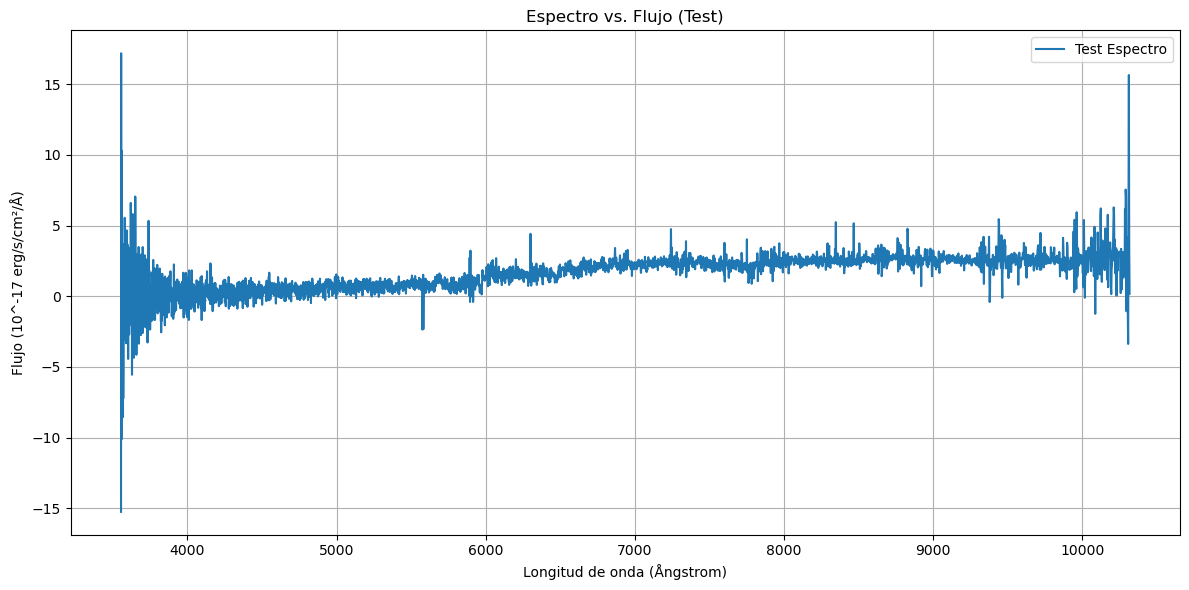

In [ ]:
# Obtener la lista inicial de archivos FITS
folder_path = r'spectrums'
files = [f for f in os.listdir(folder_path) if f.endswith('.fits')]
files = random.sample(files, len(files))
file_path = os.path.join(folder_path, files[0])

checkpoint = torch.load('storage/modelCNN_UPD3_100ktest.pth', weights_only=False)
modelCNN.load_state_dict(checkpoint['model_state_dict'])
with open('extra/scaler_modelCNN_UPD_100ktest.pkl', 'rb') as f:
    scaler = pickle.load(f)


with fits.open(file_path) as hdul:
    test_flux = hdul[1].data["flux"]
    test_loglam = hdul[1].data["loglam"]
    test_redshift = hdul[2].data["Z"][0]  # Asumiendo que Z es un array y queremos el primer valor

test_wavelength = 10 ** test_loglam

def expand_points(wavelength, flux, target_count=5000):
    # Convertir a listas para facilitar las inserciones
    wl = list(wavelength)
    fl = list(flux)
    
    # Calcular las diferencias absolutas entre puntos consecutivos
    diffs = [abs(fl[i+1] - fl[i]) for i in range(len(fl)-1)]
    # Obtener los índices ordenados de mayor a menor diferencia
    sorted_indices = sorted(range(len(diffs)), key=lambda i: diffs[i], reverse=True)
    
    # Insertar nuevos puntos utilizando los índices ordenados
    while len(wl) < target_count:
        # Se recorre la lista de índices en orden descendente para evitar problemas con el reordenamiento
        for idx in sorted_indices:
            if len(wl) >= target_count:
                break
            # Calcular la interpolación lineal entre el punto idx y el siguiente
            new_wl = (wl[idx] + wl[idx+1]) / 2
            new_fl = (fl[idx] + fl[idx+1]) / 2
            # Insertar el nuevo punto en la posición correspondiente
            wl.insert(idx+1, new_wl)
            fl.insert(idx+1, new_fl)
    
    return np.array(wl), np.array(fl)

test_wavelength, test_flux = expand_points(test_wavelength, test_flux, target_count=num_points)

# Preprocesamiento para el modelo
# Canal 0: flux; Canal 1: wavelength
input_data = np.stack([test_flux, test_wavelength], axis=0)  # (2, 5000) 2 canales de tamaño 5000
input_data = input_data.reshape(1, 2, num_points)            # (1, 2, 5000) 1 muestra, 2 canales, 5000 puntos/canal

# Normalización
nsamples, nchannels, npoints = input_data.shape # Guardar dimensionalidad inicial
input_flat = input_data.reshape(nsamples, -1) # Aplanar/concatenar (1, 10000)
input_scaled = scaler.transform(input_flat) # Normalizar
input_scaled = input_scaled.reshape(nsamples, nchannels, npoints) # Recuperar dimensionalidad incial

# Convertir a tensor
input_tensor = torch.tensor(input_scaled, dtype=torch.float32)
input_tensor = input_tensor.to(device)

# Evaluar el modelo
with torch.no_grad():
    predicted_redshift = modelCNN(input_tensor)

print("Redshift real:", test_redshift)
print("Redshift predicho:", predicted_redshift.item())

plt.figure(figsize=(12, 6))
plt.plot(test_wavelength, test_flux, label="Test Espectro")
plt.xlabel("Longitud de onda (Ångstrom)")
plt.ylabel("Flujo (10^-17 erg/s/cm²/Å)")
plt.title("Espectro vs. Flujo (Test)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()